# Introduction into Bayesian Statistics

In [ ]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt


url = "https://psmsl.org/data/obtaining/rlr.monthly.data/188.rlrdata"

# Read semicolon-separated file
df = pd.read_csv(
    url,
    sep=";",
    header=None,
    names=["sea_level", "flag", "ddd"],
    engine="python"
)

# Clean whitespace
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

# Convert numeric columns
df["decimal_year"] = pd.to_numeric(df.index, errors="coerce")
df["sea_level"] = pd.to_numeric(df["sea_level"], errors="coerce")

# Convert decimal year to monthly timestamps
year = np.floor(df["decimal_year"]).astype(int)
month = ((df["decimal_year"] - year) * 12 + 1-0.2).round().astype(int)

df["date"] = pd.to_datetime(
    {"year": year, "month": month, "day": 1},
    errors="coerce"
)

# Build pandas time series
ts = pd.Series(df["sea_level"].values, index=df["date"], name="sea_level")
ts = ts.sort_index()
ts = ts[ts>-9999]  # filter out missing data
ts=ts-ts.mean()  # demean
print(ts.head())

date
1913-01-01   -196.307578
1913-02-01   -144.307578
1913-03-01   -190.307578
1913-04-01   -132.307578
1913-05-01   -126.307578
Name: sea_level, dtype: float64


<Axes: xlabel='date'>

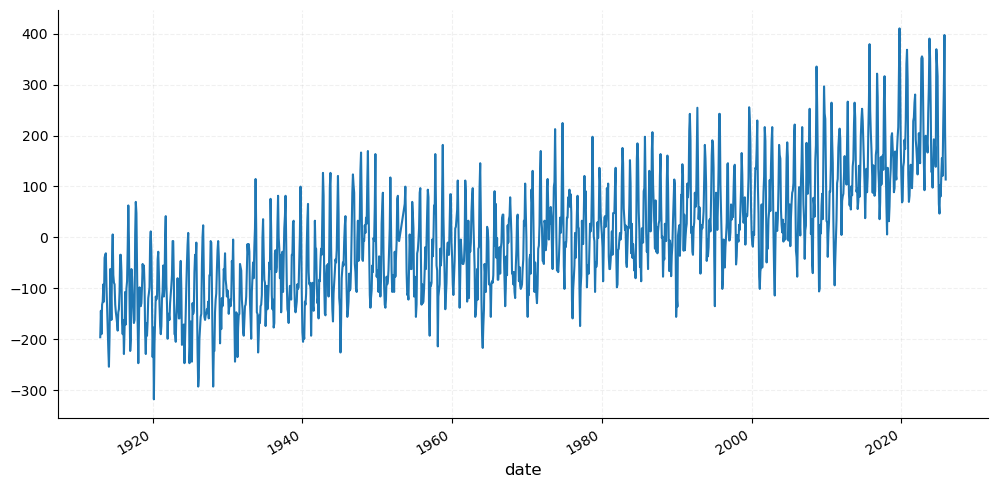

In [46]:
plt.figure(figsize=(12, 6))
ts.plot()

In [22]:
import pandas as pd

# make sure the index is datetime
TS = ts.copy()
TS.index = pd.to_datetime(TS.index)

# build a complete monthly index from first to last observation
full_index = pd.date_range(
    start=TS.index.min(),
    end=TS.index.max(),
    freq="MS",   # monthly start; use "M" or "ME" if your data are month-end
)

# reindex and insert missing months as NaN
TS_full = TS.reindex(full_index)

In [ ]:

# TS: pandas Series of monthly averaged sea level in mm
# Example:
# TS = pd.Series(...)

y = TS_full.to_numpy(dtype=float)
T = len(y)
t = np.arange(T, dtype=float)  # monthly index: 0, 1, 2, ...

with pm.Model() as model:
    # -----------------------------
    # Slow-varying background trend
    # -----------------------------
    sigma_trend = pm.HalfNormal("sigma_trend", sigma=10.0)

    trend_init = pm.Normal.dist(mu=y[0], sigma=np.std(y) if np.std(y) > 0 else 10.0)

    trend = pm.GaussianRandomWalk(
        "trend",
        sigma=sigma_trend,
        init_dist=trend_init,
        shape=T,
    )

    # -----------------------------
    # Semi-annual cycle
    # fixed amplitude + fixed phase
    # period = 6 months
    # -----------------------------
    amp_semi = pm.HalfNormal("amp_semi", sigma=50.0)
    phi_semi = pm.Uniform("phi_semi", lower=0.0, upper=2 * np.pi)

    semi_cycle = pm.Deterministic(
        "semi_cycle",
        amp_semi * pt.cos(2 * np.pi * t / 6.0 + phi_semi)
    )

    # -----------------------------
    # Annual cycle
    # amplitude follows a GRW
    # fixed phase
    # period = 12 months
    # -----------------------------
    sigma_amp_ann = pm.HalfNormal("sigma_amp_ann", sigma=5.0)

    # annual amplitude should stay positive, so model log-amplitude as GRW
    log_amp_ann_init = pm.Normal.dist(mu=np.log(10.0), sigma=1.0)

    log_amp_ann = pm.GaussianRandomWalk(
        "log_amp_ann",
        sigma=sigma_amp_ann,
        init_dist=log_amp_ann_init,
        shape=T,
    )

    amp_ann = pm.Deterministic("amp_ann", pt.exp(log_amp_ann))

    phi_ann = pm.Uniform("phi_ann", lower=0.0, upper=2 * np.pi)

    annual_cycle = pm.Deterministic(
        "annual_cycle",
        amp_ann * pt.cos(2 * np.pi * t / 12.0 + phi_ann)
    )

    # -----------------------------
    # Mean structure
    # -----------------------------
    mu = pm.Deterministic(
        "mu",
        trend + semi_cycle + annual_cycle
    )

    # -----------------------------
    # Residual noise
    # -----------------------------
    sigma = pm.HalfNormal("sigma", sigma=20.0)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

/Users/juliusoelsmann/miniconda3/envs/bayes-stats/lib/python3.14/site-packages/pymc/model/core.py:1316: ImputationWarning: Data in y_obs contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


In [30]:
with model:
    idata = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        chains=4,
        random_seed=42,
        nuts_sampler='numpyro'
    )

Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4000 [00:00<?, ?it/s]




Running chain 0:  10%|█         | 400/4000 [00:13<01:50, 32.72it/s]


Running chain 0:  15%|█▌        | 600/4000 [00:18<01:29, 37.82it/s]


Running chain 0:  25%|██▌       | 1000/4000 [00:23<00:58, 51.71it/s]


Running chain 0:  30%|███       | 1200/4000 [00:28<00:57, 48.79it/s]

Running chain 0:  45%|████▌     | 1800/4000 [00:41<00:46, 47.41it/s]

Running chain 0:  55%|█████▌    | 2200/4000 [00:48<00:34, 51.56it/s]

Running chain 0:  65%|██████▌   | 2600/4000 [00:56<00:27, 50.88it/s]

Running chain 0:  80%|████████  | 3200/4000 [01:08<00:15, 50.26it/s]

Running chain 0:  90%|█████████ | 3600/4000 [01:15<00:07, 54.26it/s]

Running chain 0:  95%|█████████▌| 3800/4000 [01:18<00:03, 57.32it/s]

Running chain 0: 100%|██████████| 4000/4000 [01:21<00:00, 48.89it/s]

























Running chain 3: 100%|██████████| 4000/4000 [02:26<00:00, 27.37it/s]



Running cha

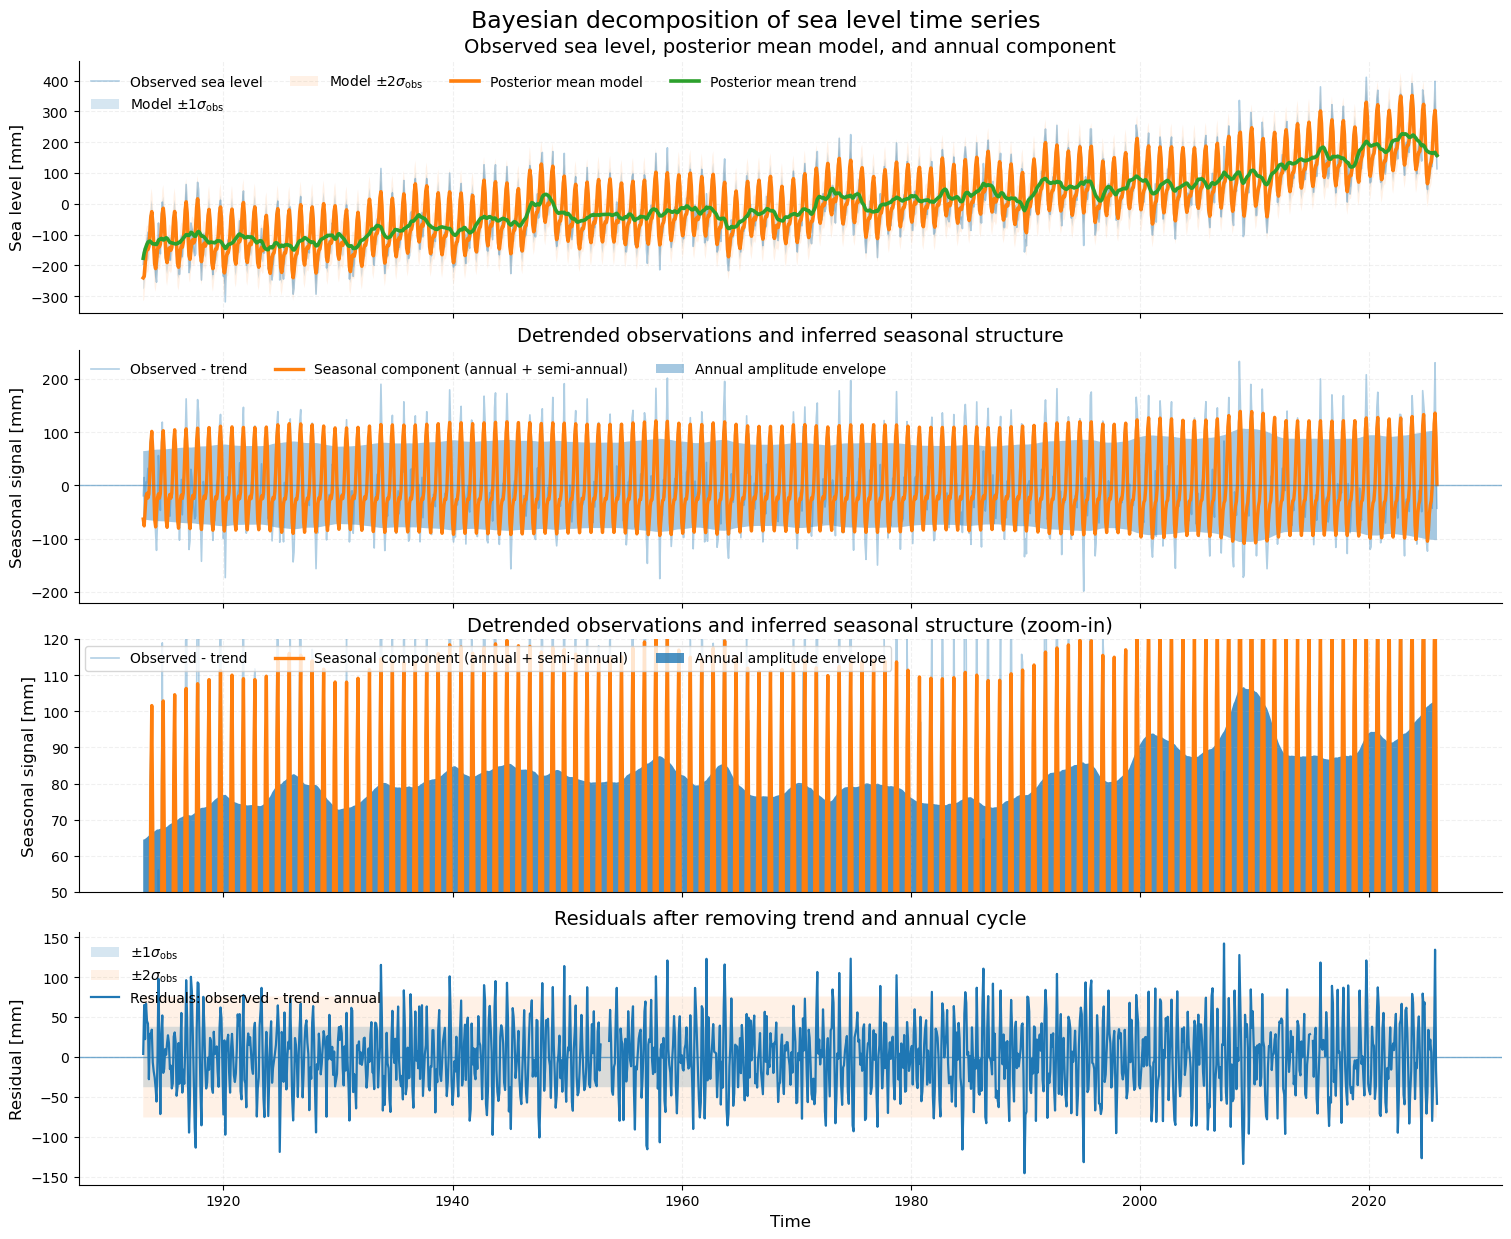

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# Data
# -----------------------------
time = TS_full.index
y = TS_full.to_numpy(dtype=float)

posterior = idata.posterior

# posterior means
mu_mean = posterior["mu"].mean(dim=("chain", "draw")).values
trend_mean = posterior["trend"].mean(dim=("chain", "draw")).values
annual_mean = posterior["annual_cycle"].mean(dim=("chain", "draw")).values
semi_mean = posterior["semi_cycle"].mean(dim=("chain", "draw")).values
amp_ann_mean = posterior["amp_ann"].mean(dim=("chain", "draw")).values

# residual noise sigma
sigma_mean = posterior["sigma"].mean(dim=("chain", "draw")).values.item()

# annual amplitude envelope
annual_upper = amp_ann_mean
annual_lower = -amp_ann_mean

# derived series
detrended_obs = y - trend_mean
seasonal_total = annual_mean + semi_mean

resid_after_trend_annual = y - trend_mean - annual_mean

# -----------------------------
# Style
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (15, 15),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axs = plt.subplots(
    4, 1,
    sharex=True,
    figsize=(15, 12),
    constrained_layout=True
)

# -----------------------------
# 1) Observations + model mean + annual cycle + sigma shading
# -----------------------------
ax = axs[0]

ax.plot(time, y, lw=1.2, alpha=0.35, label="Observed sea level")
ax.fill_between(
    time,
    mu_mean - sigma_mean,
    mu_mean + sigma_mean,
    alpha=0.18,
    label=r"Model $\pm 1\sigma_{\mathrm{obs}}$"
)
ax.fill_between(
    time,
    mu_mean - 2 * sigma_mean,
    mu_mean + 2 * sigma_mean,
    alpha=0.10,
    label=r"Model $\pm 2\sigma_{\mathrm{obs}}$"
)
ax.plot(time, mu_mean, lw=2.6, label="Posterior mean model")
ax.plot(time, trend_mean, lw=2.6, label="Posterior mean trend")
# ax.plot(time, annual_mean, lw=2.0, alpha=0.95, label="Annual cycle")

ax.set_title("Observed sea level, posterior mean model, and annual component")
ax.set_ylabel("Sea level [mm]")
ax.legend(ncol=4, loc="upper left")

# -----------------------------
# 2) Detrended observations + seasonal component + annual amplitude envelope
# -----------------------------
ax = axs[1]

ax.plot(time, detrended_obs, lw=1.2, alpha=0.35, label="Observed - trend")
ax.plot(time, seasonal_total, lw=2.4, label="Seasonal component (annual + semi-annual)")
# ax.plot(time, annual_mean, lw=1.8, alpha=0.95, label="Annual cycle")

ax.fill_between(
    time,
    annual_lower,
    annual_upper,
    alpha=0.4,
    label="Annual amplitude envelope"
)

ax.axhline(0, lw=1.0, alpha=0.5)
ax.set_title("Detrended observations and inferred seasonal structure")
ax.set_ylabel("Seasonal signal [mm]")
ax.legend(ncol=4, loc="upper left")

# -----------------------------
# 3) Detrended observations + seasonal component + annual amplitude envelope
# -----------------------------
ax = axs[2]

ax.plot(time, detrended_obs, lw=1.2, alpha=0.35, label="Observed - trend")
ax.plot(time, seasonal_total, lw=2.4, label="Seasonal component (annual + semi-annual)")
# ax.plot(time, annual_mean, lw=1.8, alpha=0.95, label="Annual cycle")

ax.fill_between(
    time,
    annual_lower,
    annual_upper,
    alpha=0.8,
    label="Annual amplitude envelope"
)

ax.set_ylim(50, 120)
ax.axhline(0, lw=1.0, alpha=0.5)
ax.set_title("Detrended observations and inferred seasonal structure (zoom-in)")
ax.set_ylabel("Seasonal signal [mm]")
ax.legend(ncol=4, loc="upper left",frameon=True)



# -----------------------------
# 4) Residuals after subtracting trend and annual cycle
#    with 1 and 2 sigma confidence shading
# -----------------------------
ax = axs[3]

ax.fill_between(
    time,
    -sigma_mean,
    sigma_mean,
    alpha=0.18,
    label=r"$\pm 1\sigma_{\mathrm{obs}}$"
)
ax.fill_between(
    time,
    -2 * sigma_mean,
    2 * sigma_mean,
    alpha=0.10,
    label=r"$\pm 2\sigma_{\mathrm{obs}}$"
)
ax.plot(time, resid_after_trend_annual, lw=1.6, label="Residuals: observed - trend - annual")
ax.axhline(0, lw=1.0, alpha=0.6)

ax.set_title("Residuals after removing trend and annual cycle")
ax.set_ylabel("Residual [mm]")
ax.set_xlabel("Time")
ax.legend(loc="upper left")

# -----------------------------
# Date formatting
# -----------------------------
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
axs[-1].xaxis.set_major_locator(locator)
axs[-1].xaxis.set_major_formatter(formatter)

fig.suptitle("Bayesian decomposition of sea level time series", fontsize=17, y=1.02)
plt.show()

